## What is Stable Diffusion?

Stable Diffusion is a powerful deep learning model that falls under the category of **generative AI**. Specifically, it's a type of **latent diffusion model** capable of generating high-quality images from text descriptions (also known as "text-to-image" generation). It can also perform other tasks like image-to-image translation, inpainting (filling in missing parts of an image), and outpainting (extending an image beyond its original borders).

### Key Concepts:

*   **Diffusion Models:** These models learn to generate data by reversing a gradual noise diffusion process. Imagine starting with pure noise and slowly transforming it into a coherent image.
*   **Latent Space:** Instead of working directly with high-resolution image pixels, Stable Diffusion operates in a compressed, lower-dimensional representation called the "latent space." This makes the process much more computationally efficient.
*   **Text-to-Image:** The core functionality allows users to describe an image using natural language prompts, and the model generates an image matching that description.

### How does it work (simplified)?

1.  **Text Encoding:** Your text prompt is first converted into a numerical representation (an embedding) that the model can understand.
2.  **Noise Generation:** The process starts with random noise in the latent space.
3.  **Iterative Denoising:** The model then iteratively removes noise from this latent representation, guided by the text embedding. At each step, it tries to predict how to make the image slightly less noisy and more aligned with your prompt.
4.  **Image Decoding:** Once the denoising process is complete, the final latent representation is decoded back into a full-resolution image.


## Setup Environment

First, let's install the necessary libraries. We'll need `diffusers` for the Stable Diffusion models and `transformers` for handling text encoding.

In [6]:
!pip install -qq diffusers transformers accelerate

## Load the Stable Diffusion Pipeline

Now we'll load the Stable Diffusion pipeline. We'll use a pre-trained model from Hugging Face's `runwayml/stable-diffusion-v1-5`  repository. This model is a good balance of quality and performance for educational purposes.

Loading the model for the first time will download its weights, which might take a few minutes depending on your internet connection.

In [7]:
import torch
from diffusers import DiffusionPipeline
from huggingface_hub import login
from google.colab import userdata

# --- IMPORTANT: Hugging Face Authentication ---
# The model 'runwayml/stable-diffusion-v1-5' might require authentication.
# If you encounter a '401 Client Error' or 'Repository Not Found' error,
# it means you need to provide a Hugging Face authentication token.

# Method: Using Colab Secrets (Recommended for convenience and security)
# 1. Get an Access Token from Hugging Face Settings -> Access Tokens (select 'read' role).
# 2. In the left sidebar of Colab, click the 'key' symbol to open the Secrets manager.
# 3. Toggle 'Notebook access' to 'on'.
# 4. Click '+ Add new secret', enter `HF_TOKEN` as the name, and paste your token into the 'Value' field.

hf_token = userdata.get('HF_TOKEN')
if hf_token:
    login(hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN secret not found. Please set it in Colab Secrets and ensure 'Notebook access' is enabled.")


Successfully logged in to Hugging Face!


# Loading the pre-trained model

Load the `runwayml/stable-diffusion-v1-5` model, which is a smaller Stable Diffusion model, with `torch_dtype=torch.bfloat16` and `enable_model_cpu_offload()` to prevent CUDA out-of-memory errors, and then generate an image using the existing prompt.

In [3]:
import torch
from diffusers import DiffusionPipeline

# Clear CUDA cache to free up memory
torch.cuda.empty_cache()
# Adding low_cpu_mem_usage=True for better memory management during loading
pipe = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.bfloat16, low_cpu_mem_usage=True)
# Instead of pipe.to("cuda"), we use enable_model_cpu_offload() to manage GPU memory more efficiently.
pipe.enable_model_cpu_offload()




model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Generate Image with Smaller Model


In [8]:
prompt = "An image of a scotty dog playing the flute"
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

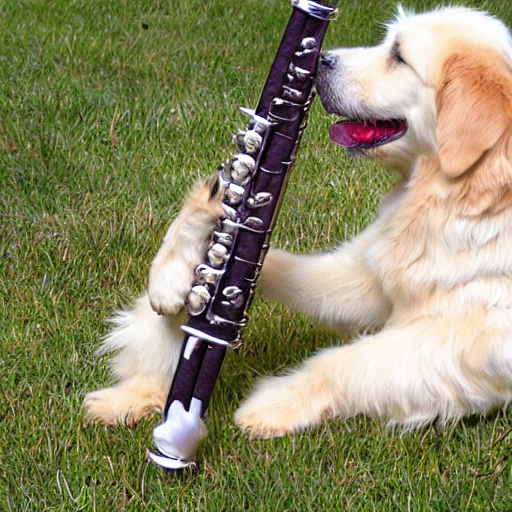

In [9]:
image

In [ ]:
prompt = "2025 McLaren MCL39 Formula One race car in las vegas Grand prix - - I need the full car"
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

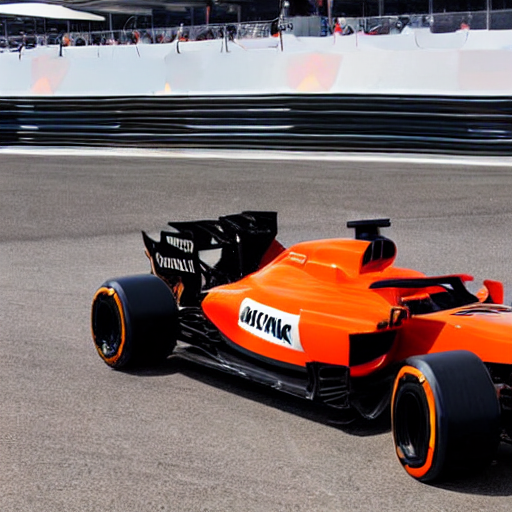

In [ ]:
image